# 📘 Clase 3 · Notebook 8 — SARIMAX: agregar variables externas (exógenas)

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 9**.

| | |
|---|---|
| **Datos** | `macrodata` de statsmodels — datos macroeconómicos trimestrales de EE. UU., 1959–2009 (203 trimestres) |
| **Tiempo estimado en casa** | 30–40 min |
| **¿Se vio en clase?** | ✅ Sí — **Demo 6** (Bloque 3), sin ejecutar la búsqueda en malla |

### 🎯 Al terminar este notebook podrás…
1. Entender qué es una **variable exógena** y cómo entra en SARIMAX.
2. Conocer la **advertencia clave**: para pronosticar necesitas los valores **futuros** de las exógenas.
3. Por qué los p-valores de los coeficientes **no** sirven para seleccionar variables.
4. Detectar un resultado “demasiado bueno” (fuga de información).

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH09/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH09
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **SARIMAX = SARIMA + X** (variables exógenas o externas).

$$y_t = \text{SARIMA}(p,d,q)(P,D,Q)_m + \sum_{i=1}^{n}\beta_i\,X_t^{(i)}$$

Es decir: un SARIMA al que le sumamos una **regresión lineal** sobre otras variables que creemos que influyen en *y*.

Analogía: para pronosticar las ventas de helado, además de mirar las ventas pasadas (SARIMA), miras el **pronóstico de temperatura** (variable exógena).

⚠️ **La trampa:** para pronosticar *y* mañana necesitas **X de mañana**. Si X también es desconocida, tendrás que pronosticarla… y acumularás errores.

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm.auto import tqdm as tqdm_notebook  # 🛠️ tqdm.auto funciona en Jupyter, VS Code y Colab
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

C:\Users\Juan David\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🧭 Cargamos el dataset incluido en statsmodels (no hace falta ningún CSV).

In [2]:
macro_econ_data = sm.datasets.macrodata.load_pandas().data
macro_econ_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


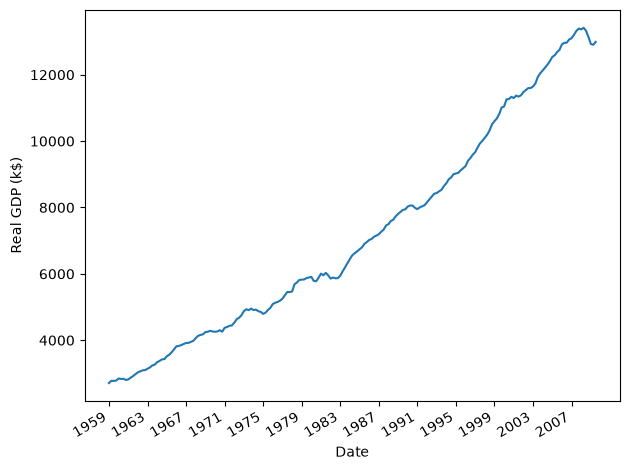

In [3]:
fig, ax = plt.subplots()

ax.plot(macro_econ_data['realgdp'])
ax.set_xlabel('Date')
ax.set_ylabel('Real GDP (k$)')

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH09_F01_peixeiro.png', dpi=300)

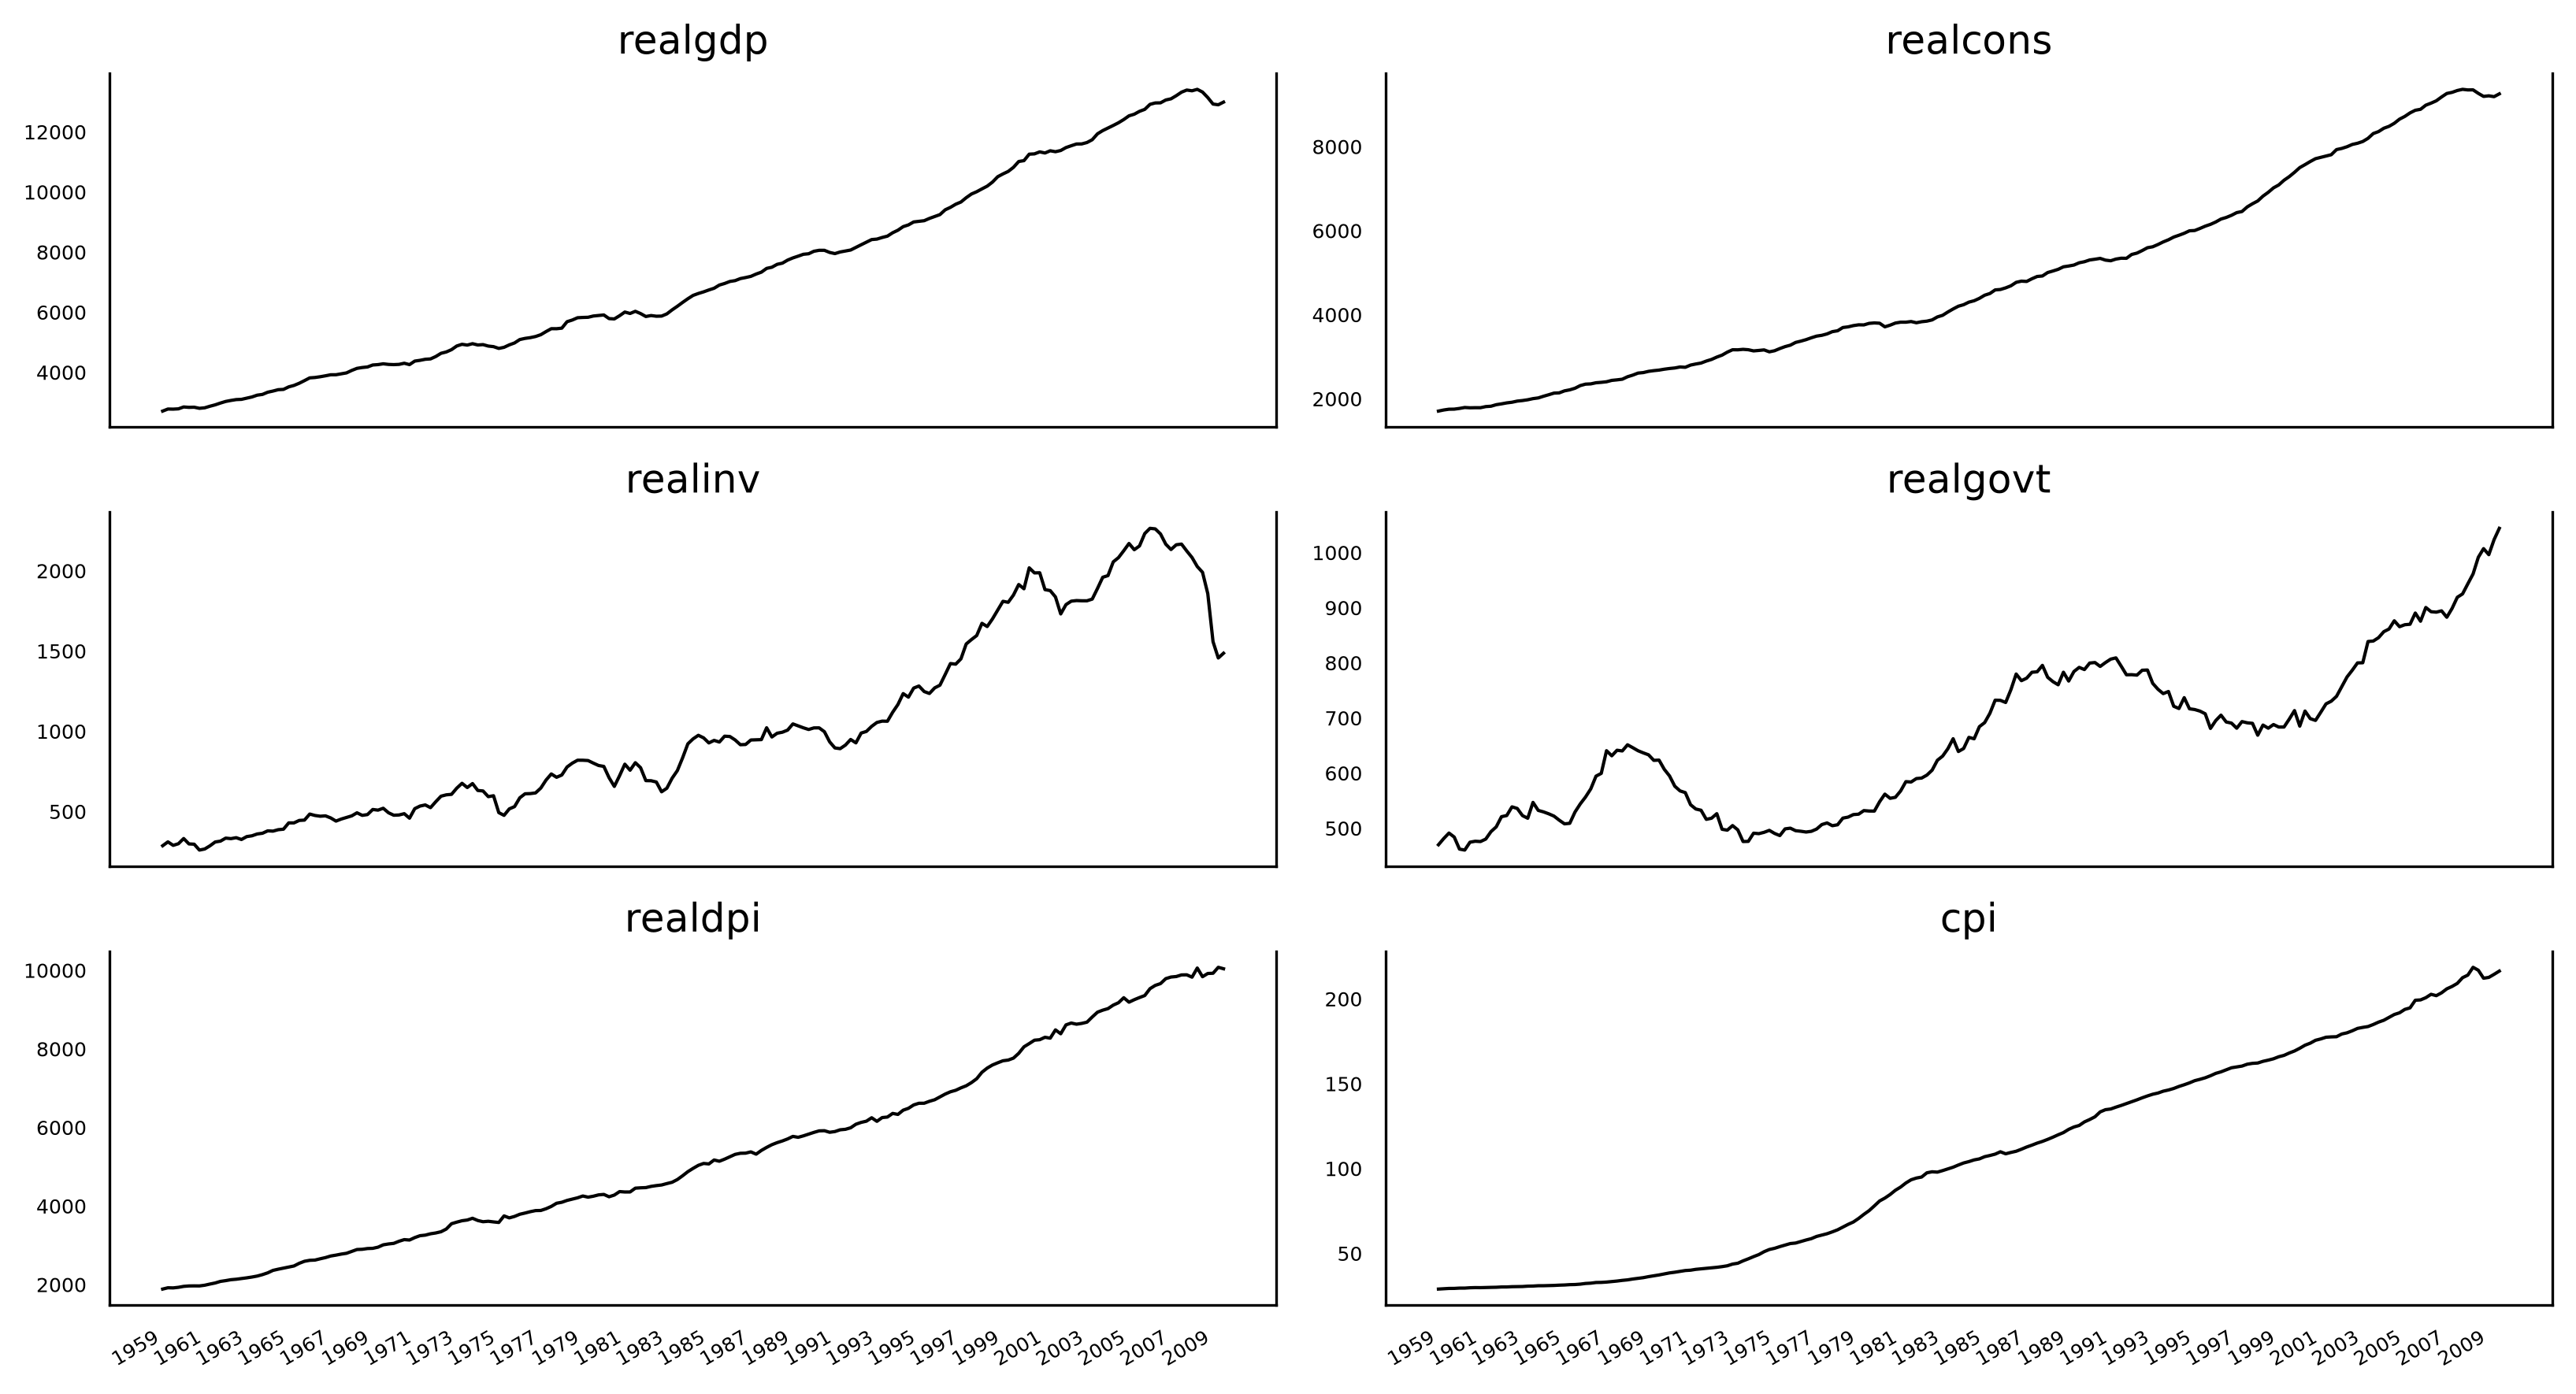

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=2, dpi=300, figsize=(11,6))

for i, ax in enumerate(axes.flatten()[:6]):
    data = macro_econ_data[macro_econ_data.columns[i+2]]
    
    ax.plot(data, color='black', linewidth=1)
    ax.set_title(macro_econ_data.columns[i+2])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.setp(axes, xticks=np.arange(0, 208, 8), xticklabels=np.arange(1959, 2010, 2))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('figures/CH09_F02_peixeiro.png', dpi=300)

🔎 Todas las series tienen tendencia creciente; `cpi` (precios) crece de forma más suave y continua.

🧭 **Objetivo (endógena):** `realgdp` (PIB real).
**Exógenas:** `realcons` (consumo), `realinv` (inversión), `realgovt` (gasto de gobierno), `realdpi` (ingreso disponible), `cpi` (índice de precios).

💡 Por teoría económica, PIB ≈ Consumo + Inversión + Gasto público + Exportaciones netas. **Recuerda esto: será importante al final.**

In [5]:
target = macro_econ_data['realgdp']
exog = macro_econ_data[['realcons', 'realinv', 'realgovt', 'realdpi', 'cpi']]

🧭 ¿*y* es estacionaria? ADF.

In [6]:
ad_fuller_result = adfuller(target)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 1.7504627967647166
p-value: 0.9982455372335032


🔎 p ≈ 1 → no estacionaria.

In [7]:
target_diff = target.diff()

ad_fuller_result = adfuller(target_diff[1:])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -6.305695561658106
p-value: 3.327882187668224e-08


🔎 Con una diferencia: estacionaria → **d = 1**. No hay estacionalidad evidente → probaremos D = 0.

🧭 Misma búsqueda en malla, ahora pasando también `exog`.

In [8]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [9]:
p = range(0, 4, 1)
d = 1
q = range(0, 4, 1)
P = range(0, 4, 1)
D = 0
Q = range(0, 4, 1)
s = 4

parameters = product(p, q, P, Q)
parameters_list = list(parameters)

⏱️ **Esta celda es lenta.** La búsqueda en malla (*grid search*) ajusta un modelo por **cada** combinación de órdenes. Dejamos una bandera `EJECUTAR_BUSQUEDA = False` para que puedas seguir el notebook sin esperar: en ese caso se muestra el resultado ya conocido. Cuando tengas tiempo, cámbiala a `True` y compruébalo tú mismo.

🧭 p, q, P, Q ∈ {0,…,3}, d = 1, D = 0, m = 4 → **256 modelos**.

In [10]:
EJECUTAR_BUSQUEDA = False   # ⏱️ True = 256 modelos SARIMAX, puede tardar bastante

target_train = target[:200]
exog_train = exog[:200]

if EJECUTAR_BUSQUEDA:
    result_df = optimize_SARIMAX(target_train, exog_train, parameters_list, d, D, s)
else:
    print('Búsqueda omitida. Resultado conocido (libro, sección 9.2): mejor modelo = (3,1,3)(0,0,0)4.')
    result_df = pd.DataFrame({'(p,q,P,Q)': [(3, 3, 0, 0)], 'AIC': ['ver libro']})
result_df

Búsqueda omitida. Resultado conocido (libro, sección 9.2): mejor modelo = (3,1,3)(0,0,0)4.


,"(p,q,P,Q)",AIC
0,"(3, 3, 0, 0)",ver libro


🧭 Ajustamos el mejor modelo: **SARIMAX(3,1,3)(0,0,0)₄** — el AIC eligió **no** usar componente estacional.

⚠️ En el `summary()` verás un p-valor por cada exógena. **No** elimines variables porque su p-valor sea > 0.05: ese p-valor solo prueba si el coeficiente es distinto de 0, no si la variable ayuda a pronosticar. La selección la hace el AIC.

In [11]:
best_model = SARIMAX(target_train, exog_train, order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
best_model_fit = best_model.fit(disp=False)

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  200
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -859.428
Date:                Fri, 02 Oct 2026   AIC                           1742.856
Time:                        15:07:10   BIC                           1782.376
Sample:                             0   HQIC                          1758.851
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9668      0.044     21.757      0.000       0.880       1.054
realinv        1.0148      0.033     31.035      0.000       0.951       1.079
realgovt       0.7243      0.127      5.719      0.0

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

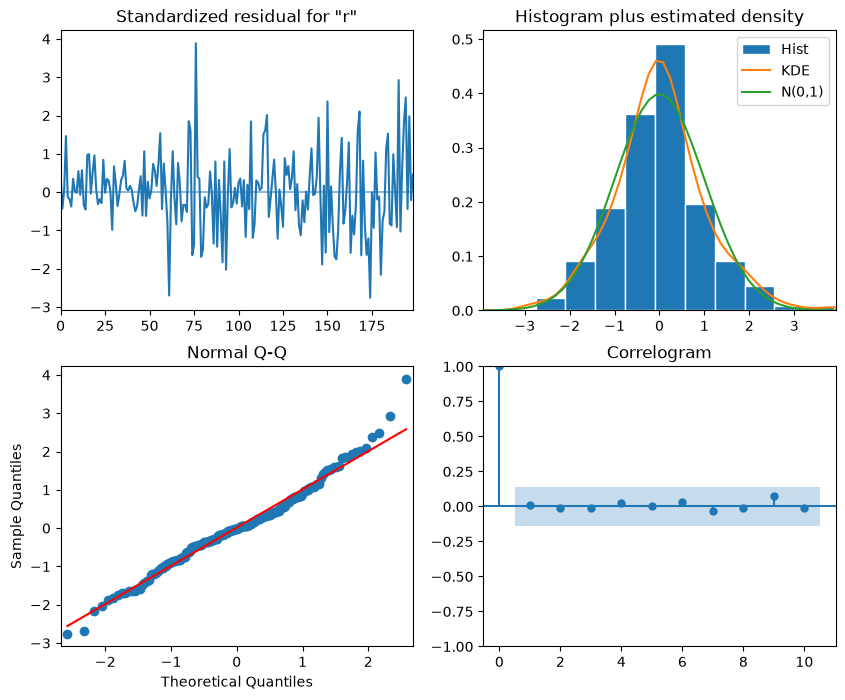

In [12]:
best_model_fit.plot_diagnostics(figsize=(10,8));

plt.savefig('figures/CH09_F05_peixeiro.png', dpi=300)

🛠️ **Cambio respecto al libro — prueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [13]:
residuals = best_model_fit.resid

# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.760363
2     0.902659
3     0.976180
4     0.882684
5     0.947364
6     0.977185
7     0.985859
8     0.994231
9     0.994784
10    0.997871
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? True


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

💡 **¿Por qué solo pronosticamos 1 paso?** Por la trampa de las exógenas: si pronosticamos varios trimestres, necesitaríamos los valores futuros de consumo, inversión, etc. Pronosticando **un trimestre a la vez** (y re-entrenando), el libro evita ese problema.

🧭 Comparamos contra el baseline **último valor**. El test son los últimos 7 trimestres.

In [14]:
def recursive_forecast(endog: Union[pd.Series, list], exog: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = endog[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'SARIMAX':
        pred_SARIMAX = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMAX.extend(oos_pred)
            
        return pred_SARIMAX

In [15]:
target_train = target[:196]
target_test = target[196:]

pred_df = pd.DataFrame({'actual': target_test})

TRAIN_LEN = len(target_train)
HORIZON = len(target_test)
WINDOW = 1

pred_last_value = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_SARIMAX = recursive_forecast(target, exog, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

pred_df['pred_last_value'] = pred_last_value
pred_df['pred_SARIMAX'] = pred_SARIMAX

pred_df

,actual,pred_last_value,pred_SARIMAX
196,13366.865,13391.249,13344.063247
197,13415.266,13366.865,13373.512919
198,13324.600,13415.266,13378.804244
199,13141.920,13324.600,13327.960185
200,12925.410,13141.920,13133.615236
201,12901.504,12925.410,12887.689400
202,12990.341,12901.504,12873.790859


In [16]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [17]:
mape_last = mape(pred_df.actual, pred_df.pred_last_value)
mape_SARIMAX = mape(pred_df.actual, pred_df.pred_SARIMAX)

print(mape_last, mape_SARIMAX)

0.736849498653785 0.7027638345106416


🔎 Resultado esperado (libro): último valor ≈ **0.74 %** vs. SARIMAX ≈ **0.70 %**. ¡Casi un empate! Sin baseline habríamos celebrado un 0.70 % “espectacular”.

## 🔬 Nota del experto: un detalle sutil del código del libro

Dentro de `recursive_forecast`, la línea `res.get_prediction(exog=exog)` **no** genera un pronóstico hacia el futuro: sin `start`/`end`, `get_prediction` devuelve predicciones **dentro de la muestra**. Por eso `.iloc[-1]` es el valor *ajustado* del último trimestre de entrenamiento, y lo comparamos con el trimestre siguiente.

La forma correcta de pronosticar un paso adelante es `res.get_forecast(steps=1, exog=<X del trimestre a predecir>)`. Ejecuta la celda de abajo: el MAPE baja muchísimo (≈ 0.26 %). **¿Buena noticia? No tan rápido.** Para lograrlo le damos al modelo el consumo, la inversión y el gasto del **mismo trimestre** que queremos predecir, y el PIB es prácticamente su suma. En la vida real esos datos se publican **al mismo tiempo** que el PIB: no los tendrías para pronosticar.

✅ **Lección:** un resultado **sospechosamente bueno** suele indicar una **fuga de información** (*data leakage*). Pregúntate siempre: *¿tendría estos datos en el momento de hacer el pronóstico?*

In [18]:
# 🔬 Pronóstico 1 paso adelante 'correcto' — pero usando X del mismo trimestre (¡fuga de información!)
pred_forecast = []
for i in range(TRAIN_LEN, TRAIN_LEN + HORIZON):
    res = SARIMAX(target[:i], exog[:i], order=(3,1,3), seasonal_order=(0,0,0,4),
                  simple_differencing=False).fit(disp=False)
    pred_forecast.append(res.get_forecast(steps=1, exog=exog[i:i+1]).predicted_mean.iloc[0])

pred_df['pred_SARIMAX_forecast'] = pred_forecast
print('MAPE con get_forecast + X contemporánea:', round(mape(pred_df.actual, pred_df.pred_SARIMAX_forecast), 3), '%')
pred_df

MAPE con get_forecast + X contemporánea: 0.255 %


,actual,pred_last_value,pred_SARIMAX,pred_SARIMAX_forecast
196,13366.865,13391.249,13344.063247,13374.802229
197,13415.266,13366.865,13373.512919,13359.610941
198,13324.600,13415.266,13378.804244,13327.671155
199,13141.920,13324.600,13327.960185,13126.076228
200,12925.410,13141.920,13133.615236,12868.677330
201,12901.504,12925.410,12887.689400,12867.087598
202,12990.341,12901.504,12873.790859,13050.262991


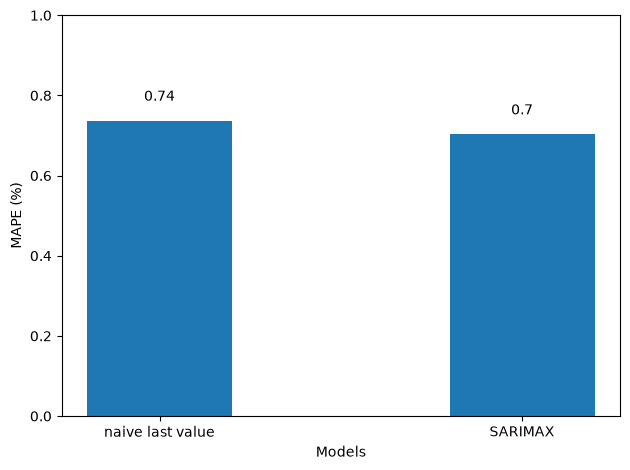

In [19]:
fig, ax = plt.subplots()

x = ['naive last value', 'SARIMAX']
y = [mape_last, mape_SARIMAX]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 1)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.05, s=str(round(value,2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH09_F06_peixeiro.png', dpi=300)

---
## ✅ Resumen
- **SARIMAX** = SARIMA + regresión sobre variables externas.
- Para pronosticar *h* pasos necesitas **X de esos *h* pasos**: o las conoces (p. ej., días festivos, precio que tú fijas) o tienes que pronosticarlas.
- La selección de variables se hace con el **AIC**, no con los p-valores de los coeficientes.
- **Siempre** compara contra un baseline, y desconfía de los resultados demasiado buenos.

🔗 **Para seguir por tu cuenta:** Capítulo 10 (**VAR**, varias series que se influyen mutuamente) y Capítulo 11 (proyecto integrador: recetas de antidiabéticos en Australia). Después, la Parte 3 del libro (deep learning).

### 🏠 Ejercicios para casa
`CH09_exercises_solution.ipynb`: repite el ejercicio usando solo las exógenas que crees que **sí** conocerías de antemano.

### 🧠 Autoevaluación
- Da un ejemplo de variable exógena que **sí** se conoce hacia el futuro y otro de una que no.
- ¿Por qué un MAPE de 0.26 % en este ejercicio debería despertar sospechas?
